In [51]:
#Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

#config
DATA_DIR = r"dataset/holy basil"
METADATA_FILE = os.path.join(DATA_DIR, "metadata.csv")
MODEL_DIR = r"models/"
MODELS_TO_COMPARE = ['random_forest_model.pkl', 'gradient_boosting_model.pkl', 'xgboost_model.pkl']
MODEL_PATH = r"models/random_forest_model.pkl"


## Plant Piano

### inspecting raw data

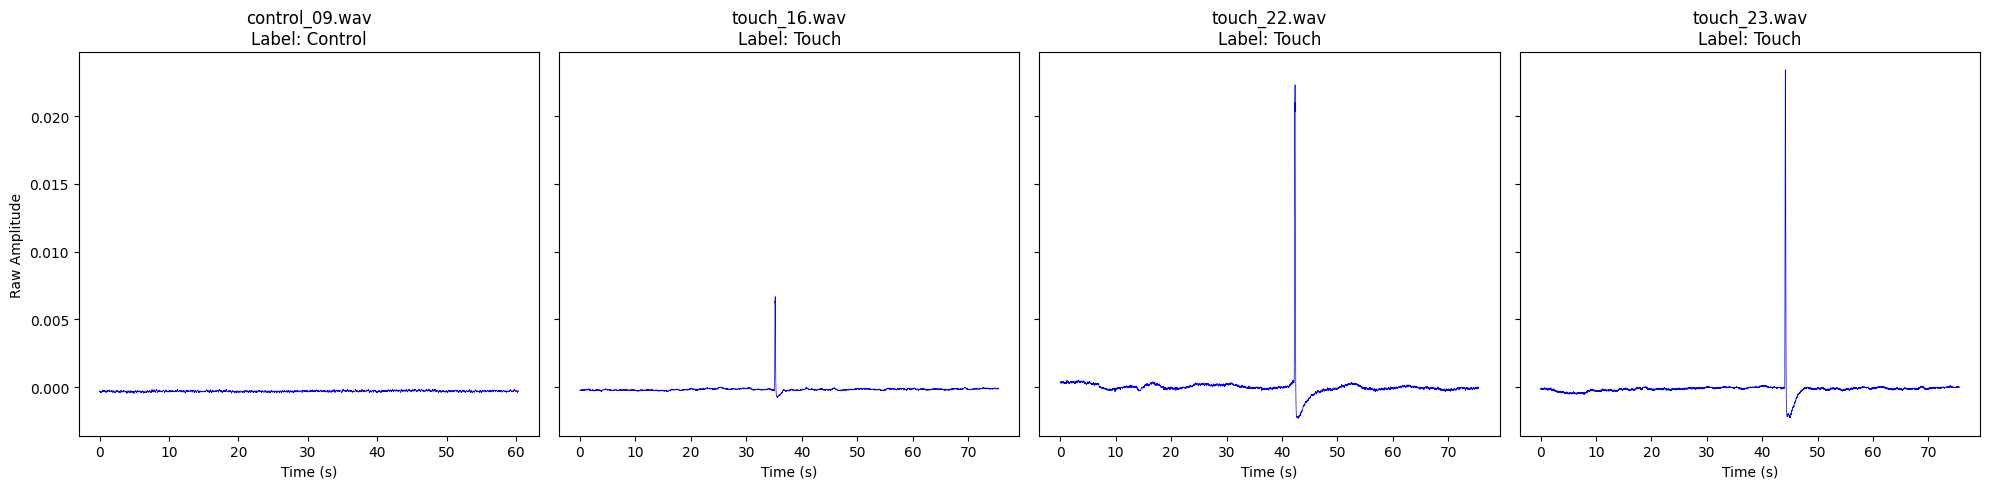

In [52]:
# Load metadata
df = pd.read_csv(METADATA_FILE)

# Select samples: 1 Control (label 0) and 3 random Touch (label 1)
control_sample = df[df['label'] == 0].sample(1)
touch_samples = df[df['label'] == 1].sample(3)
selected_samples = pd.concat([control_sample, touch_samples])

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (idx, row) in enumerate(selected_samples.iterrows()):
    sr, audio = wavfile.read(os.path.join(DATA_DIR, row['filename']))

    # Convert to float
    audio = audio.astype(np.float32) / 32768.0
    time = np.arange(len(audio)) / sr

    axes[i].plot(time, audio, linewidth=0.5, color='blue')
    axes[i].set_title(f"{row['filename']}\nLabel: {'Touch' if row['label']==1 else 'Control'}")
    axes[i].set_xlabel("Time (s)")
    if i == 0: axes[i].set_ylabel("Raw Amplitude")

plt.tight_layout()
plt.show()

### DC Offset removal

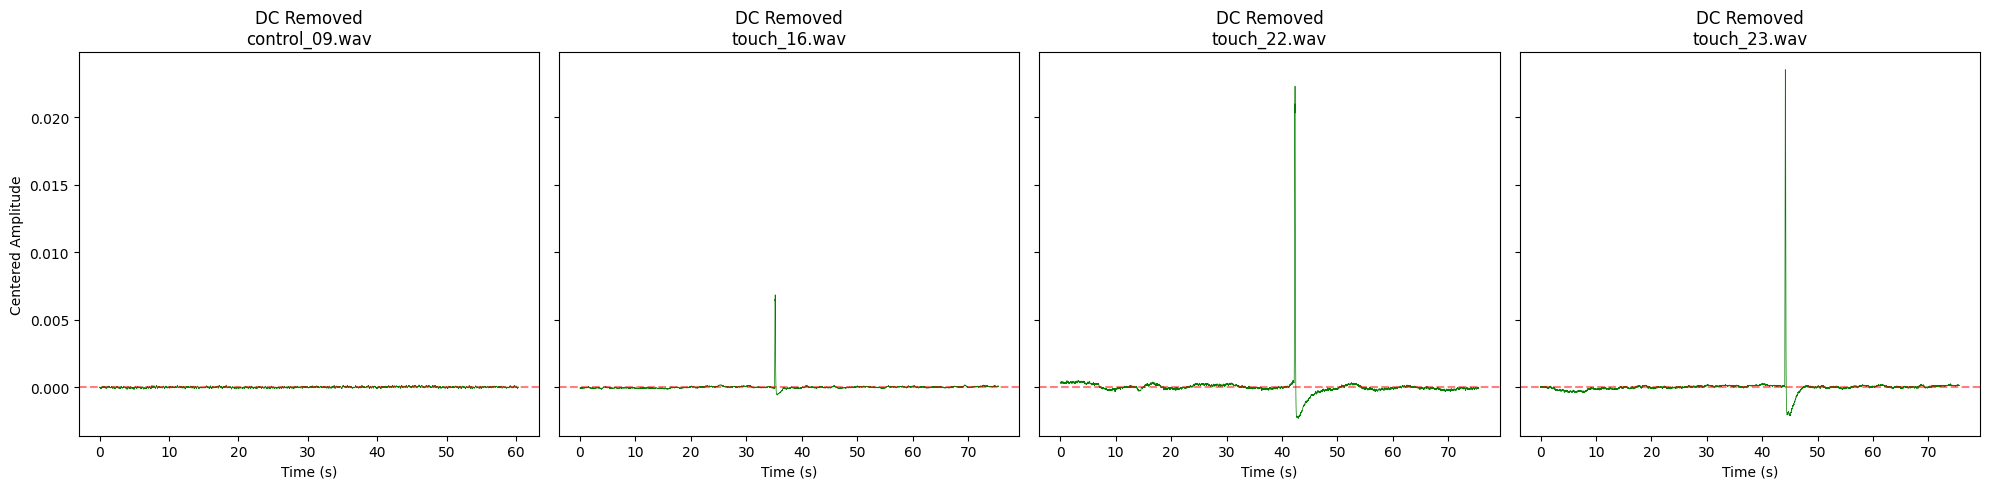

In [53]:
# Re-plotting with DC Offset Removal
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for i, (idx, row) in enumerate(selected_samples.iterrows()):
    sr, audio = wavfile.read(os.path.join(DATA_DIR, row['filename']))
    audio = audio.astype(np.float32) / 32768.0

    # DC Offset Removal
    audio_centered = audio - np.mean(audio)

    time = np.arange(len(audio_centered)) / sr
    axes[i].plot(time, audio_centered, linewidth=0.5, color='green')
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5) # Center line
    axes[i].set_title(f"DC Removed\n{row['filename']}")
    axes[i].set_xlabel("Time (s)")
    if i == 0: axes[i].set_ylabel("Centered Amplitude")

plt.tight_layout()
plt.show()

In [7]:
raw_mean = np.mean(audio)
centered_mean = np.mean(audio_centered)

print(f"Raw Mean: {raw_mean:.10f}")
print(f"Centered Mean: {centered_mean:.10f}")

Raw Mean: -0.0000975585
Centered Mean: 0.0000000000


### feature engine & feature importance

In [54]:
def calculate_features(window):
    """Calculates the 'Big Five' features for a signal window"""
    return {
        'RMS': np.sqrt(np.mean(window**2)),
        'Peak-to-Peak': np.ptp(window),
        'Std_Dev': np.std(window),
        'Percentile_90': np.percentile(np.abs(window), 90),
        'MAV': np.mean(np.abs(window))
    }

# Process entire dataset
all_features = []

for idx, row in df.iterrows():
    sr, audio = wavfile.read(os.path.join(DATA_DIR, row['filename']))
    audio = audio.astype(np.float32) / 32768.0
    audio = audio - np.mean(audio) # Preprocess

    # Calculate features for the whole recording
    stats = calculate_features(audio)
    stats['filename'] = row['filename']
    stats['label'] = row['label']
    all_features.append(stats)

# Create Feature DataFrame
feature_results = pd.DataFrame(all_features)

# Show comparison: Average features by Label
print("--- Average Feature Values by Class ---")
display(feature_results.groupby('label')[['RMS', 'Peak-to-Peak', 'Std_Dev', 'Percentile_90', 'MAV']].mean())

# Show first few rows
print("\n--- First 5 Rows of Extracted Features ---")
display(feature_results.sample(5))

--- Average Feature Values by Class ---


,RMS,Peak-to-Peak,Std_Dev,Percentile_90,MAV
label,,,,,
0,0.000081,0.000557,0.000081,0.000106,0.000057
1,0.000793,0.020637,0.000793,0.000457,0.000273



--- First 5 Rows of Extracted Features ---


,RMS,Peak-to-Peak,Std_Dev,Percentile_90,MAV,filename,label
0,0.000044,0.000305,0.000044,0.000063,0.000034,control_01.wav,0
33,0.000637,0.019196,0.000637,0.000503,0.000273,touch_19.wav,1
41,0.000577,0.013275,0.000577,0.000701,0.000326,touch_27.wav,1
43,0.001410,0.012268,0.001410,0.002069,0.001187,touch_29.wav,1
28,0.000197,0.006897,0.000197,0.000088,0.000052,touch_14.wav,1


### inference

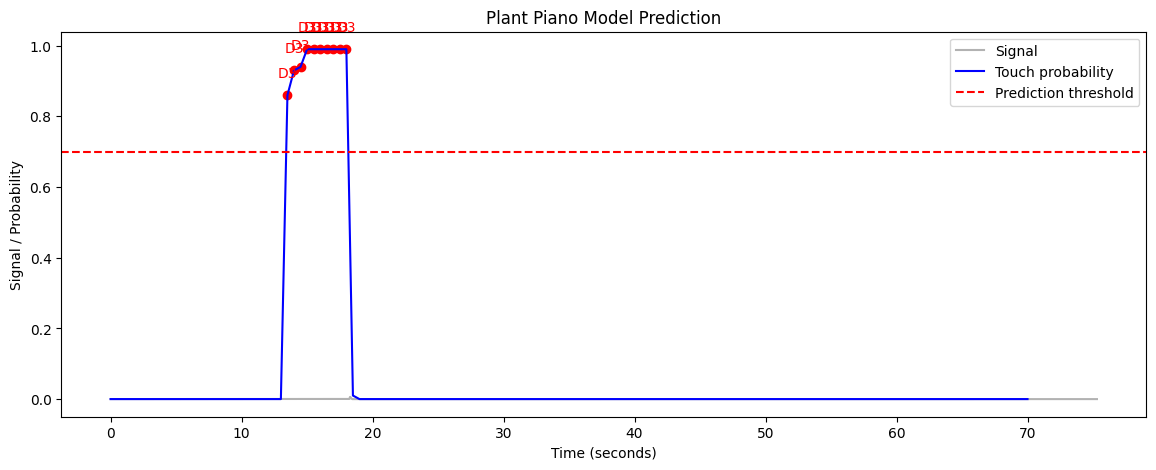

In [62]:
def note_from_amp(a):
      if a < 0.004: return "C3"
      if a < 0.008: return "D3"
      if a < 0.012: return "E3"
      if a < 0.020: return "G3"
      if a < 0.028: return "A3"
      if a < 0.035: return "C4"
      if a < 0.045: return "D4"
      if a < 0.055: return "E4"
      if a < 0.070: return "G4"
      if a < 0.090: return "A4"
      return "C5"

wav_file = "dataset/holy basil/touch_04.wav"
sr, audio = wavfile.read(wav_file)

audio = audio.astype("float32") / 32768.0
if audio.ndim > 1:
    audio = audio.mean(axis=1)
audio = audio - audio.mean()

window = int(5 * sr)
hop = int(0.5 * sr)
threshold = 0.7

times, probs, notes = [], [], []

for start in range(0, len(audio) - window, hop):
    chunk = audio[start:start + window]
    f = calculate_features(chunk)

    X = np.array([[
        f["RMS"],
        f["Peak-to-Peak"],
        f["Std_Dev"],
        f["Percentile_90"],
        f["MAV"]
    ]])

    prob = model.predict_proba(scaler.transform(X))[0, 1]
    times.append(start / sr)
    probs.append(prob)
    notes.append(note_from_amp(f["Peak-to-Peak"]) if prob > threshold else "")
plt.figure(figsize=(14, 5))
plt.plot(np.arange(len(audio)) / sr, audio, color="gray", alpha=0.6, label="Signal")
plt.plot(times, probs, color="blue", label="Touch probability")
plt.axhline(threshold, color="red", linestyle="--", label="Prediction threshold")

for t, p, note in zip(times, probs, notes):
    if note:
        plt.scatter(t, p, color="red")
        plt.text(t, p + 0.05, note, color="red", ha="center")

plt.title("Plant Piano Model Prediction")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal / Probability")
plt.legend()
plt.show()